# 04 Sentiment Analysis using a German Language Model

## Objective

The purpose of this notebook is to analyse open-ended survey comments using a dedicated German sentiment model and to derive continuous sentiment measures suitable for downstream analytics and dashboard visualisation.

The previous proof-of-concept relied on a zero-shot classification approach to estimate emotional dimensions from text. While this approach demonstrated the technical feasibility of the workflow, it also showed limitations regarding classification consistency and interpretability, particularly for more nuanced emotional dimensions.

To improve the quality and stability of sentiment estimates, this notebook uses **German Sentiment BERT** (`oliverguhr/german-sentiment-bert`), one of the most widely used and extensively validated sentiment-analysis models for German-language text. The model was trained on a large and diverse corpus consisting of reviews, social-media content, dialogue data, and benchmark datasets, making it well suited for analysing natural German text. 【1-753e24】

## Why This Model?

The model was selected for several reasons:

- it is specifically trained for German-language sentiment analysis,
- it demonstrates strong performance across multiple domains,
- it provides probability estimates for positive, neutral, and negative sentiment,
- and it can be used to derive a continuous valence score rather than only categorical labels. 【1-256cf4】

Compared to the previous zero-shot baseline, the model is expected to produce more stable and linguistically grounded sentiment estimates for German survey comments. 【1-c841e4】

## Analytical Approach

The workflow consists of four steps:

1. Load the cleaned survey-comment dataset.
2. Apply the sentiment model to each comment.
3. Generate continuous sentiment indicators based on prediction probabilities.
4. Export the enriched dataset for dashboarding and exploratory analysis.

The resulting sentiment scores can be used as a first approximation of the **valence** dimension within affective frameworks such as the Core Affect Model.

## Important Limitation

The sentiment model directly estimates only sentiment polarity (positive, neutral, negative).

Although sentiment provides a useful representation of **valence**, it does not directly measure **arousal**. Therefore, the results of this notebook should be interpreted as sentiment- and valence-oriented indicators rather than a complete operationalisation of a dimensional emotion model.

Additional analyses will be required to derive activation, emotional granularity, body-budget indicators, and contextual emotional concepts.

## Imports

The following libraries are required for data handling, visualisation, sentiment inference, and result export.

In [ ]:
# ============================================================
# Imports
# ============================================================

# Data handling
import pandas as pd
import numpy as np

# Paths
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm import tqdm

# German Sentiment Model
from germansentiment import SentimentModel


## Load Data

The analysis is performed on the cleaned dataset produced during the exploratory data analysis stage.

Using the cleaned dataset ensures consistency across all subsequent analysis notebooks.

In [3]:
# ============================================================
# Load Data
# ============================================================

DATA_PATH = Path(
    "../data/processed/synthetic_eda_ready.csv"
)

data = pd.read_csv(
    DATA_PATH
)

print(data.shape)

data.head()


(500, 80)


,id,start,ende,organisation,bereich,team_effizienz,staerken_nutzen,zusammenarbeit_team,psychologische_sicherheit,info_fuehrung_veraenderung,...,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score,flag_speeder,answer_std,flag_straightliner,flag_quality
0,1,2026-01-02 13:43:00,2026-01-02 13:57:00,[Organization],IN-AL (Innovationsfeld Alpha),5.0,3.0,5.0,5.0,5.0,...,3.25,3.500000,3.125000,2.800000,3.333333,4.0,False,0.972472,False,False
1,2,2026-01-04 15:18:00,2026-01-04 15:31:00,[Organization],IN-AL (Innovationsfeld Alpha),4.0,3.0,5.0,5.0,2.0,...,3.25,2.166667,2.625000,2.714286,2.777778,3.8,False,1.113970,False,False
2,3,2026-01-03 15:23:00,2026-01-03 15:30:00,[Organization],KE-EP (Kernbereich Epsilon),4.0,3.0,4.0,4.0,3.0,...,2.75,2.400000,2.875000,2.833333,3.111111,2.8,False,0.799019,False,False
3,4,2026-01-01 13:00:00,2026-01-01 13:06:00,[Organization],IN-AL (Innovationsfeld Alpha),5.0,4.0,4.0,4.0,4.0,...,4.50,3.000000,3.857143,3.714286,3.777778,4.0,False,0.760509,False,False
4,5,2026-01-03 08:42:00,2026-01-03 09:00:00,[Organization],ZU-BE (Zukunftssegment Beta),4.0,2.0,5.0,4.0,4.0,...,3.50,4.166667,3.250000,2.833333,3.333333,4.2,False,0.993189,False,False


## Prepare Comments

Only valid comments are retained for sentiment analysis.

In [4]:
# ============================================================
# Prepare Comments
# ============================================================

data = data.loc[
    data["has_comment"] == True
].copy()

data["freitext_kommentar"] = (
    data["freitext_kommentar"]
    .fillna("")
    .astype(str)
    .str.strip()
)

print(
    f"Comments available: {len(data):,}"
)

Comments available: 482


## Load Sentiment Model

A pre-trained German sentiment model is used to estimate sentiment polarity for each comment.

The model predicts positive, negative, and neutral sentiment and provides probability estimates that can later be transformed into continuous sentiment measures.

In [5]:
# ============================================================
# Load Model
# ============================================================

model = SentimentModel()

print("German Sentiment Model loaded successfully.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

German Sentiment Model loaded successfully.


## Load German Sentiment Model

The sentiment analysis is performed using a pre-trained German-language transformer model.

The model predicts positive, neutral, and negative sentiment probabilities for each comment. These probabilities will later be transformed into continuous sentiment measures suitable for exploratory analysis and dashboard visualisation.

In [7]:
# ============================================================
# Load German Sentiment Model
# ============================================================

from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="oliverguhr/german-sentiment-bert",
    top_k=None
)

print("German Sentiment BERT loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

German Sentiment BERT loaded successfully.


In [8]:
classifier(
    "Ich freue mich sehr über die Zusammenarbeit."
)

[[{'label': 'positive', 'score': 0.9876234531402588},
  {'label': 'negative', 'score': 0.011727317236363888},
  {'label': 'neutral', 'score': 0.0006491747335530818}]]

## Sentiment Inference

The sentiment model is applied to all comments.

For each comment, the model returns probabilities for:

- positive sentiment,
- negative sentiment,
- neutral sentiment.

A continuous valence score is then calculated as:

Valence = Positive Probability − Negative Probability

This creates a continuous sentiment dimension ranging from approximately -1 (very negative) to +1 (very positive).

In [9]:
# ============================================================
# Sentiment Inference
# ============================================================

results = []

for text in tqdm(
    data["freitext_kommentar"],
    desc="Sentiment Analysis"
):

    prediction = classifier(
        text,
        truncation=True
    )[0]

    # In Dictionary umwandeln
    scores = {
        item["label"]: item["score"]
        for item in prediction
    }

    positive_prob = scores["positive"]
    negative_prob = scores["negative"]
    neutral_prob = scores["neutral"]

    # Kontinuierliche Valenz
    valence = (
        positive_prob
        - negative_prob
    )

    # Dominantes Label
    sentiment_label = max(
        scores,
        key=scores.get
    )

    results.append(
        {
            "sentiment_label": sentiment_label,
            "positive_prob": positive_prob,
            "negative_prob": negative_prob,
            "neutral_prob": neutral_prob,
            "continuous_valence": valence,
        }
    )

results = pd.DataFrame(results)

print(
    f"Analysed {len(results):,} comments."
)

Sentiment Analysis: 100%|██████████| 482/482 [00:13<00:00, 37.04it/s]

Analysed 482 comments.


In [10]:
results.head()

,sentiment_label,positive_prob,negative_prob,neutral_prob,continuous_valence
0,positive,0.951704,0.036966,0.011329,0.914738
1,negative,0.005659,0.994011,0.000330,-0.988352
2,positive,0.987088,0.012612,0.000299,0.974476
3,negative,0.002592,0.996904,0.000504,-0.994312
4,negative,0.017471,0.950969,0.031560,-0.933498


## Merge Sentiment Results

The generated sentiment probabilities and continuous valence scores are merged back into the analytical dataset.

This creates a sentiment-enriched dataset that can be used for exploratory analysis, validation, and dashboard development.

In [12]:
# ============================================================
# Merge Results
# ============================================================

data = data.reset_index(drop=True)

data["sentiment_label"] = results["sentiment_label"]

data["positive_prob"] = results["positive_prob"]
data["negative_prob"] = results["negative_prob"]
data["neutral_prob"] = results["neutral_prob"]

data["continuous_valence"] = results["continuous_valence"]

print(
    f"Rows: {len(data):,}"
)

display(
    data[
        [
            "freitext_kommentar",
            "sentiment_label",
            "continuous_valence"
        ]
    ].head()
)

Rows: 482


,freitext_kommentar,sentiment_label,continuous_valence
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",positive,0.914738
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,negative,-0.988352
2,"Ich finde die Richtung richtig, auch wenn der ...",positive,0.974476
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",negative,-0.994312
4,Aus meiner Sicht: Die neue Struktur ergibt für...,negative,-0.933498


In [13]:
# ============================================================
# Distribution Check
# ============================================================

display(
    data["sentiment_label"]
    .value_counts()
    .to_frame("count")
)

display(
    data["continuous_valence"]
    .describe()
)

,count
sentiment_label,
negative,269
positive,152
neutral,61


count    482.000000
mean      -0.238048
std        0.831300
min       -0.998824
25%       -0.976617
50%       -0.866544
75%        0.843723
max        0.999100
Name: continuous_valence, dtype: float64

The continuous valence score ranges almost across the full theoretical spectrum from -1 to +1. The median value is clearly negative, indicating that a substantial share of comments is classified as strongly negative. At the same time, the upper quartile is strongly positive, suggesting a polarised distribution with both highly negative and highly positive comments.

Der kontinuierliche Valenzwert deckt nahezu den gesamten theoretischen Bereich von -1 bis +1 ab. Der Median ist deutlich negativ, was darauf hinweist, dass ein großer Teil der Kommentare als stark negativ klassifiziert wird. Gleichzeitig liegt das obere Quartil deutlich im positiven Bereich. Die Verteilung wirkt daher polarisiert, mit vielen stark negativen, aber auch deutlich positiven Kommentaren.

In [15]:
# ============================================================
# Export Sentiment Dataset
# ============================================================

output_file = (
    "../data/results/synthetic_sentiment_enriched.csv"
)

data.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig",
    decimal=","
)

print(f"Saved: {output_file}")

Saved: ../data/results/synthetic_sentiment_enriched.csv


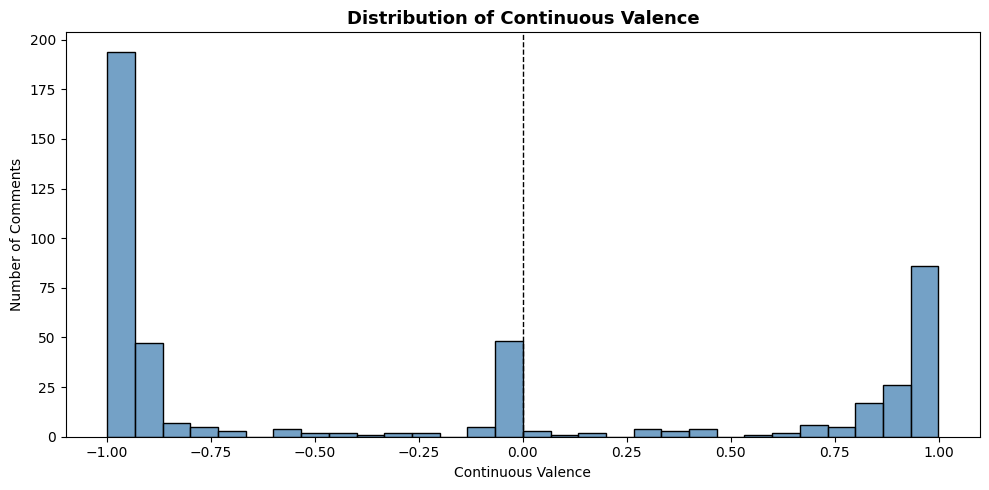

In [16]:
# ============================================================
# Visualise Continuous Valence
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data["continuous_valence"],
    bins=30,
    color="steelblue"
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Distribution of Continuous Valence",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Continuous Valence")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()